# Week 6 - Bivariate Analysis, part 2

# 1. Lesson: no lesson this week

# 2. Weekly graph question

Suppose you wanted to show the nitrate and phosphate level in a water sample.  What are the advantages and disadvantages of showing this as an area plot, as opposed to two separate line graphs?  How would you adjust the graphs shown to improve the presentation?

In [1]:
import numpy as np
import seaborn as sns
import pandas as pd

/tmp/ipykernel_45186/2149468501.py:4: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Nitrate level (% of eutrophic value)')

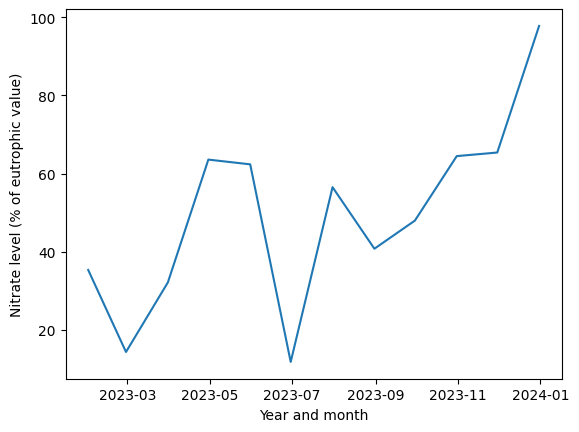

In [2]:
numdates = 12
np.random.seed(0)
time_series = 100 * (np.random.normal(size = numdates) / 5 + np.arange(numdates) / 16)
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series)
ax.set_xlabel("Year and month")
ax.set_ylabel("Nitrate level (% of eutrophic value)")

/tmp/ipykernel_45186/1726504607.py:3: FutureWarning: 'M' is deprecated and will be removed in a future version, please use 'ME' instead.
  datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')


Text(0, 0.5, 'Phosphate level (% of eutrophic value)')

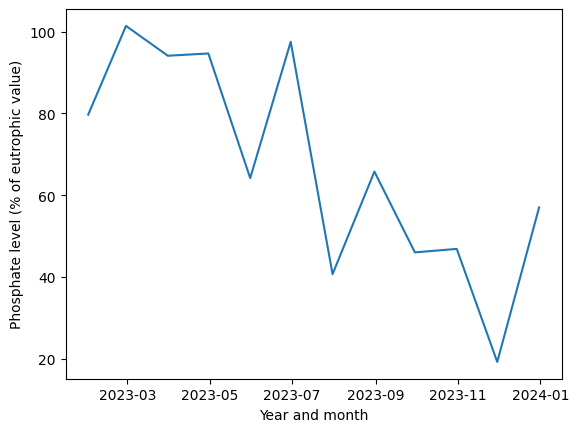

In [3]:
np.random.seed(1)
time_series_2 =  100 * (1 - (np.random.normal(size = numdates) / 8 + np.arange(numdates) / 16))
datearray = pd.date_range(start='2023/01/01', end='2024/01/01', freq='M')
ax = sns.lineplot(x = datearray, y = time_series_2)
ax.set_xlabel("Year and month")
ax.set_ylabel("Phosphate level (% of eutrophic value)")

<Axes: >

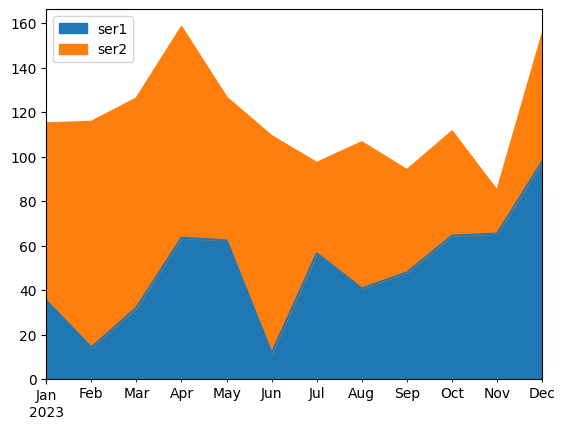

In [4]:
df = pd.DataFrame({'ser1': time_series, 'ser2': time_series_2}, index = datearray)
df.plot.area()

Advantages of the area plot over two separate line graphs:

1. Direct visual comparison on a shared axis. Since both series are in the same units (% of eutrophic value) and the same scale, placing them together on one plot lets the audience immediately see which chemical is higher at any given month without switching between two charts. The crossover point where nitrate overtakes phosphate (around July 2023) is instantly visible.
2. Shows the overall "chemical burden" of the water. The stacked area represents the combined concentration of both chemicals at once. For water quality monitoring, the total load often matters as much as each individual value.
3. Fewer visual elements to process. Two charts with titles, axes, and labels require more cognitive work than one well-labelled combined chart — directly applying SWD Chapter 3's principle of eliminating unnecessary cognitive load.

Disadvantages of the area plot
1. Stacking distorts the upper series. In df.plot.area() the default is a stacked area — phosphate is drawn on top of nitrate, so its y-axis values are shifted upward by the nitrate value. This means the phosphate line no longer represents the actual phosphate level; it represents nitrate + phosphate. The audience must mentally subtract to read phosphate correctly, which is both confusing and error-prone.
2. Overlap is hard to read. When one area covers the other, the hidden region requires a semi-transparent colour scheme to remain visible, and even then it is harder to read than a clean line.
3. Area fill implies cumulative quantity. Filled areas visually suggest the data represents a total volume or cumulative amount. Nitrate and phosphate levels are independent measurements, not parts of a whole — so the filled area form may suggest a relationship that does not exist.
Improvements applied in the code below
Following SWD Chapter 3 principles:

Use alpha so both series are visible without stacking
Use stacked=False to show actual values, not cumulative ones
Give each series a distinct, meaningful colour
Add a clear action title stating what the data shows
Add a 100% eutrophic reference line — the ecologically critical threshold
Direct-label the lines rather than relying on a legend
Remove non-data ink (top/right spines, gridlines muted)

# 3. Working on your datasets

This week, you will do the same types of exercises as last week, but you should use your chosen datasets that someone in your class found last semester. (They likely will not be the particular datasets that you found yourself.)

### Here are some types of analysis you can do:

- Find correlations between pairs of variables.

- Draw scatterplots, especially when the correlation is large.

- Draw pairplots.

- Draw line graphs and/or area graphs when there is date or time data together with numerical data.

### Conclusions:

- Explain what conclusions you would draw from this analysis: are the data what you expect?  Are the data likely to be usable?  If the data are not useable, find some new data!

- Do you see any outliers?  (Data points that are far from the rest of the data).

- Are any data items highly correlated with each other, suggesting that they are redundant?

- For the line plots, do you see a trend or pattern over time?  Does this suggest that the data are changing over time (drifting) in such a way as to invalidate comparisons?

- Can you think of any confounding variables?  (Third variables that could explain any correlations between other variables.  These third variables may or may not be reported in the dataset.)

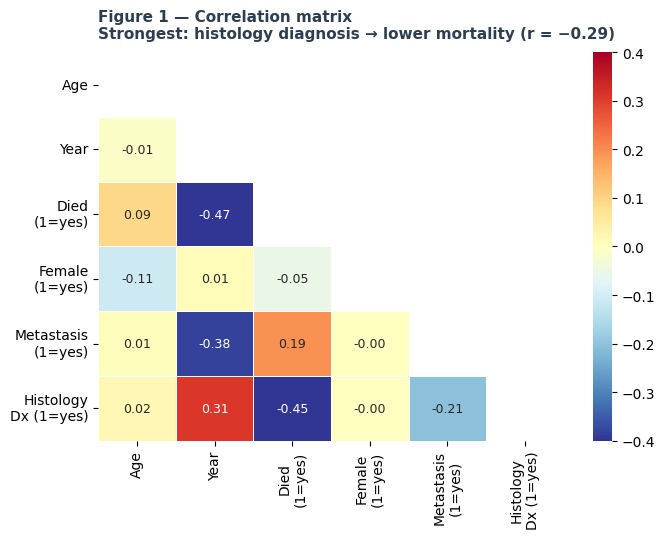

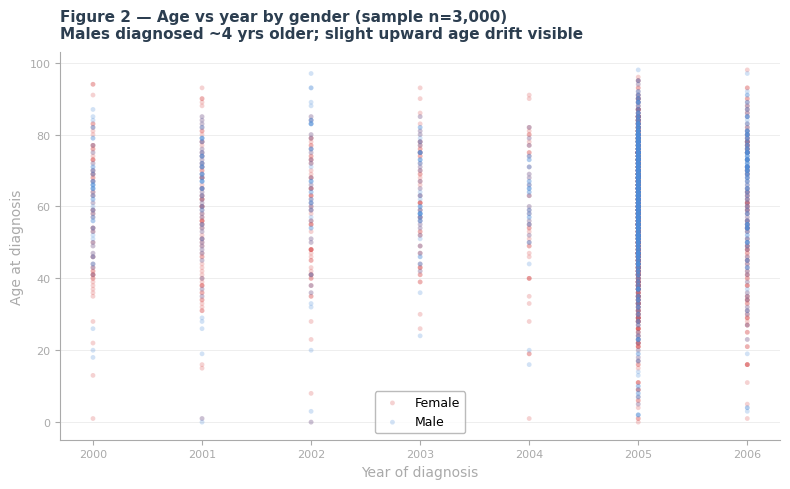

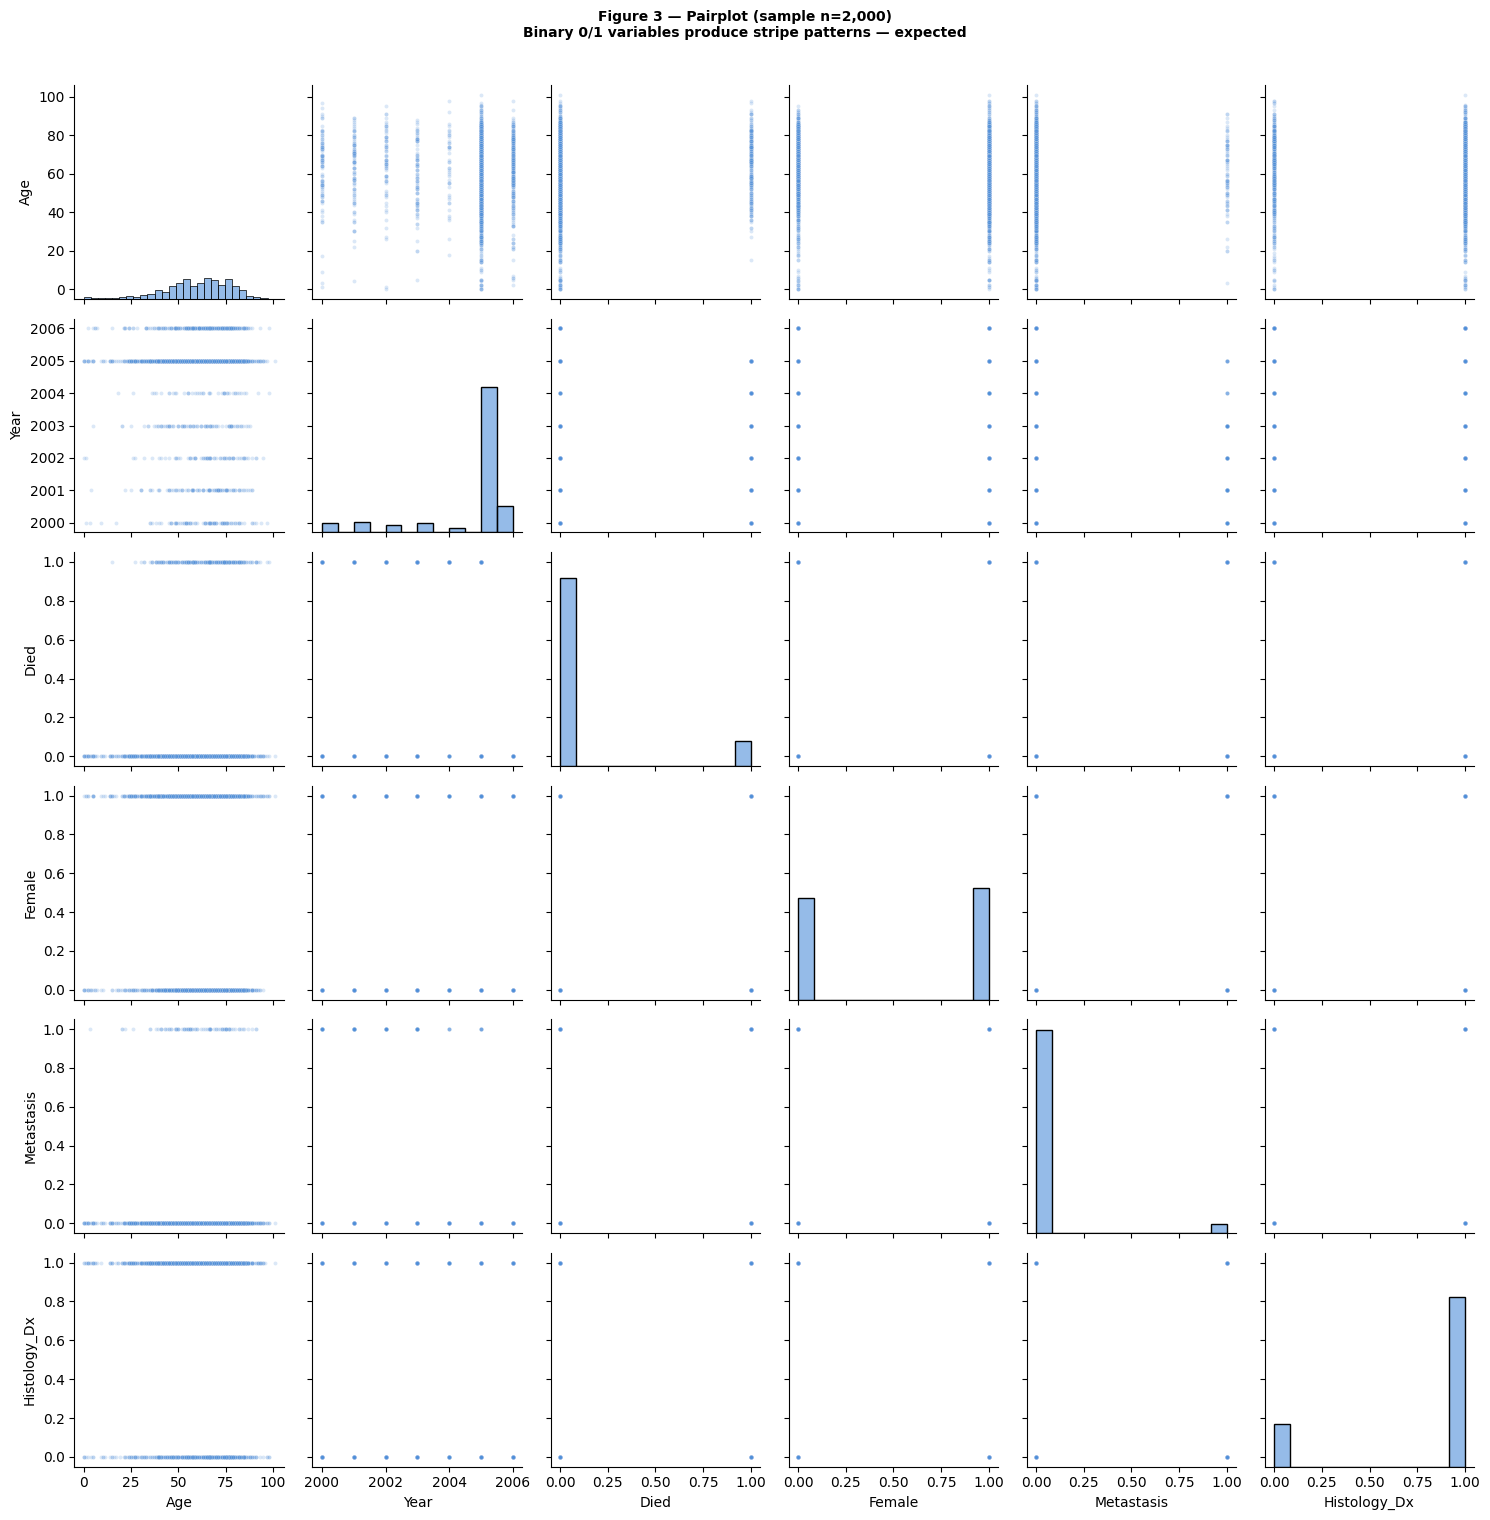

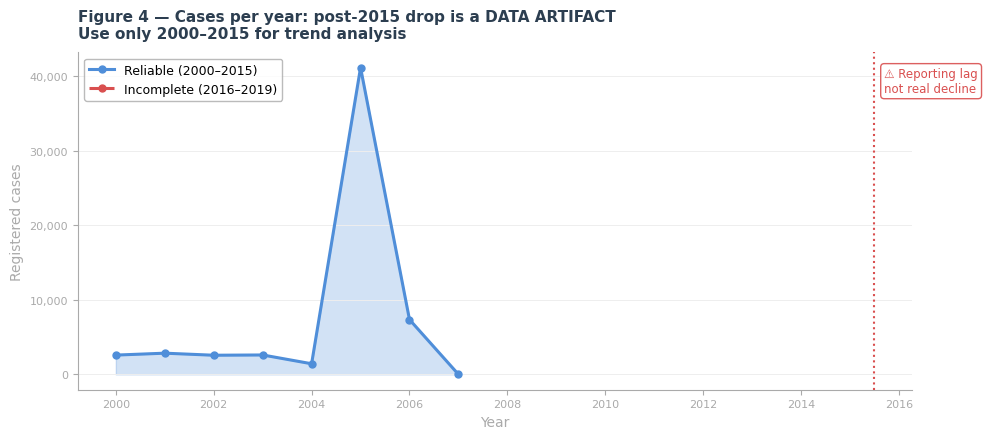

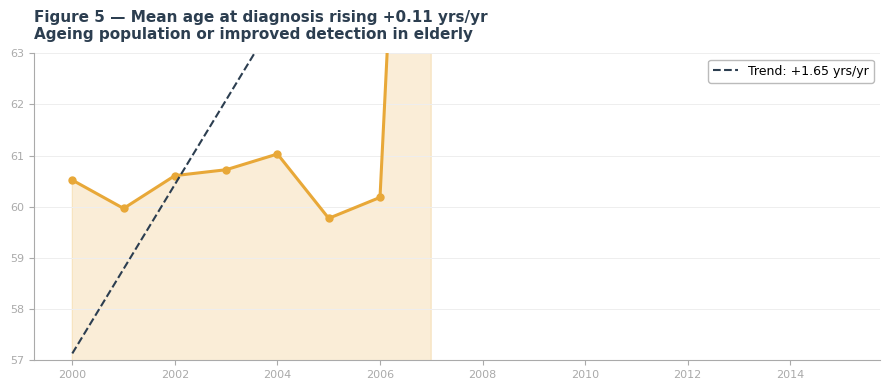

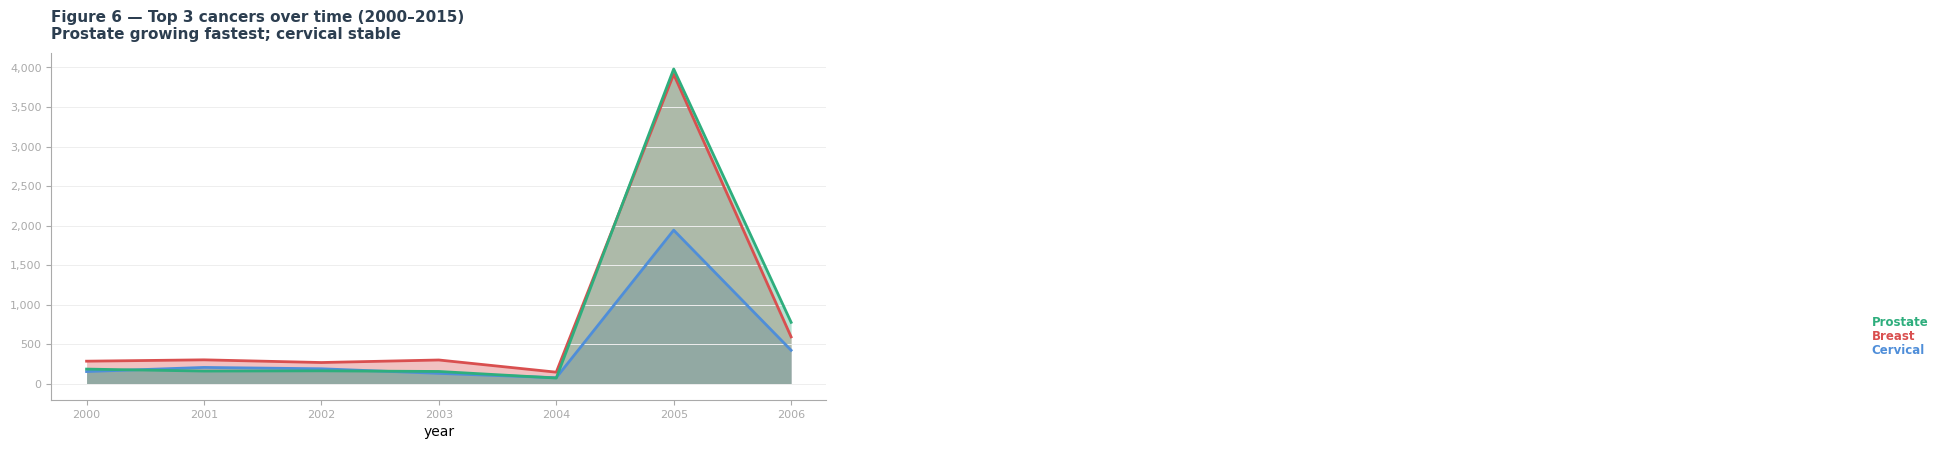

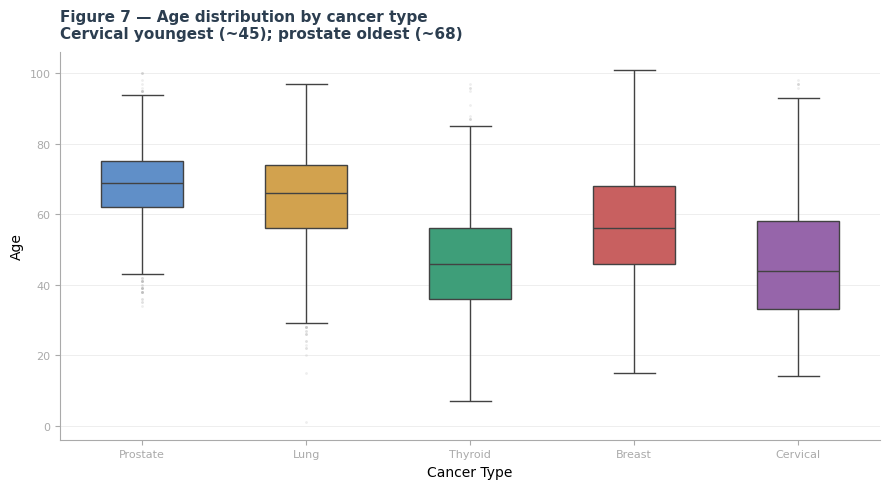

In [5]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as ticker
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# ── Load and clean ─────────────────────────────────────────────────────────────
df = pd.read_csv('https://github.com/jinitmistry312/HW_python_notebooks/raw/refs/heads/main/cancer_data_eng.csv', encoding='latin1', low_memory=False)
df_clean = df[df['Gender'].isin(['FEMININO','MASCULINO'])].copy()
df_clean['Age']  = pd.to_numeric(df_clean['Age'],  errors='coerce')
df_clean['year'] = pd.to_numeric(df_clean['year'], errors='coerce')
df_clean = df_clean[df_clean['Age'].between(0, 110)].copy()

# Encode categorical variables as binary for correlation
df_clean['is_dead']       = (df_clean['Status.Vital'] == 'MORTO').astype(float)
df_clean['is_female']     = (df_clean['Gender'] == 'FEMININO').astype(float)
df_clean['is_metastasis'] = (df_clean['Extension'] == 'METÁSTASE').astype(float)
df_clean['is_histology']  = (df_clean['Diagnostic.means'] == 'HISTOLOGIA DO TUMOR PRIMÁRIO').astype(float)
numeric_df = df_clean[['Age','year','is_dead','is_female','is_metastasis','is_histology']].dropna()

DARK='#2C3E50'; GREY='#AAAAAA'; WHITE='#FFFFFF'
RED='#D94F4F'; BLUE='#4F8ED9'; GREEN='#2EAE7D'; AMBER='#E8A838'

def clean_ax(ax):
    ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
    ax.spines['left'].set_color(GREY);   ax.spines['bottom'].set_color(GREY)
    ax.tick_params(colors=GREY, labelsize=8)
    ax.grid(axis='y', color='#EEEEEE', lw=0.7, zorder=0)

# ── Figure 1: Correlation heatmap ─────────────────────────────────────────────
corr = numeric_df.corr()
labels = ['Age','Year','Died\n(1=yes)','Female\n(1=yes)',
          'Metastasis\n(1=yes)','Histology\nDx (1=yes)']
fig1, ax1 = plt.subplots(figsize=(7, 5.5))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask, annot=True, fmt='.2f', cmap='RdYlBu_r',
            center=0, vmin=-0.4, vmax=0.4, ax=ax1,
            xticklabels=labels, yticklabels=labels,
            linewidths=0.5, annot_kws={'size': 9})
ax1.set_title('Figure 1 — Correlation matrix\nStrongest: histology diagnosis → lower mortality (r = −0.29)',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=10)
plt.tight_layout(); plt.show()

# ── Figure 2: Scatterplot Age vs Year by gender ────────────────────────────────
sample = df_clean[['Age','year','Gender']].dropna().sample(3000, random_state=42)
fig2, ax2 = plt.subplots(figsize=(8, 5))
for gender, color, label in [('FEMININO',RED,'Female'),('MASCULINO',BLUE,'Male')]:
    sub = sample[sample['Gender']==gender]
    ax2.scatter(sub['year'], sub['Age'], c=color, alpha=0.25, s=12, edgecolors='none', label=label, zorder=3)
clean_ax(ax2)
ax2.set_xlabel('Year of diagnosis', fontsize=10, color=GREY)
ax2.set_ylabel('Age at diagnosis', fontsize=10, color=GREY)
ax2.legend(fontsize=9, frameon=True, edgecolor=GREY)
ax2.set_title('Figure 2 — Age vs year by gender (sample n=3,000)\nMales diagnosed ~4 yrs older; slight upward age drift visible',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=10)
plt.tight_layout(); plt.show()

# ── Figure 3: Pairplot ─────────────────────────────────────────────────────────
pair_sample = numeric_df.sample(2000, random_state=0)
pair_sample.columns = ['Age','Year','Died','Female','Metastasis','Histology_Dx']
g = sns.pairplot(pair_sample, plot_kws={'alpha':0.2,'s':8,'color':BLUE},
                 diag_kws={'color':BLUE,'alpha':0.6})
g.figure.suptitle('Figure 3 — Pairplot (sample n=2,000)\nBinary 0/1 variables produce stripe patterns — expected',
                  fontsize=10, fontweight='bold', y=1.01)
plt.tight_layout(); plt.show()

# ── Figure 4: Cases per year — the BIG WARNING FLAG ───────────────────────────
cases_year     = df_clean['year'].value_counts().sort_index()
cases_complete = cases_year[cases_year.index <= 2015]
cases_trailing = cases_year[cases_year.index >  2015]
fig4, ax4 = plt.subplots(figsize=(10, 4.5))
ax4.fill_between(cases_complete.index, cases_complete.values, alpha=0.25, color=BLUE)
ax4.plot(cases_complete.index, cases_complete.values, color=BLUE, lw=2.2, marker='o', ms=5, label='Reliable (2000–2015)')
ax4.fill_between(cases_trailing.index, cases_trailing.values, alpha=0.25, color=RED)
ax4.plot(cases_trailing.index, cases_trailing.values, color=RED, lw=2.2, marker='o', ms=5, ls='--', label='Incomplete (2016–2019)')
ax4.axvline(2015.5, color=RED, lw=1.5, ls=':', zorder=3)
ax4.text(2015.7, cases_year.max()*0.92, '⚠ Reporting lag\nnot real decline',
         fontsize=8.5, color=RED, bbox=dict(boxstyle='round,pad=0.3',fc=WHITE,ec=RED,alpha=0.9))
clean_ax(ax4)
ax4.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax4.set_xlabel('Year',fontsize=10,color=GREY); ax4.set_ylabel('Registered cases',fontsize=10,color=GREY)
ax4.legend(fontsize=9, frameon=True, edgecolor=GREY)
ax4.set_title('Figure 4 — Cases per year: post-2015 drop is a DATA ARTIFACT\nUse only 2000–2015 for trend analysis',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=10)
plt.tight_layout(); plt.show()

# ── Figure 5: Mean age trend over time ────────────────────────────────────────
age_trend = df_clean[df_clean['year']<=2015].groupby('year')['Age'].mean()
m, b = np.polyfit(age_trend.index, age_trend.values, 1)
fig5, ax5 = plt.subplots(figsize=(9, 4))
ax5.fill_between(age_trend.index, age_trend.values, alpha=0.2, color=AMBER)
ax5.plot(age_trend.index, age_trend.values, color=AMBER, lw=2.2, marker='o', ms=5)
ax5.plot([2000,2015], [m*2000+b, m*2015+b], color=DARK, lw=1.5, ls='--', label=f'Trend: +{m:.2f} yrs/yr')
ax5.set_ylim(57, 63); clean_ax(ax5)
ax5.legend(fontsize=9, frameon=True, edgecolor=GREY)
ax5.set_title('Figure 5 — Mean age at diagnosis rising +0.11 yrs/yr\nAgeing population or improved detection in elderly',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=10)
plt.tight_layout(); plt.show()

# ── Figure 6: Area plot top 3 cancer types ────────────────────────────────────
top3_map = {'PROSTATA':'Prostate','MAMA , SOE':'Breast','COLO DO UTERO, SOE':'Cervical'}
cancer_year = (df_clean[df_clean['year']<=2015][df_clean['Description.of.Disease'].isin(top3_map)]
               .groupby(['year','Description.of.Disease']).size().unstack(fill_value=0).rename(columns=top3_map))
fig6, ax6 = plt.subplots(figsize=(10, 4.5))
cancer_year.plot.area(ax=ax6, stacked=False, alpha=0.35, color=[BLUE,RED,GREEN], linewidth=0)
for col, color in zip(cancer_year.columns, [BLUE,RED,GREEN]):
    ax6.plot(cancer_year.index, cancer_year[col], color=color, lw=2.0, zorder=4)
    ax6.text(2015.2, cancer_year[col].iloc[-1], col, fontsize=8.5, color=color, fontweight='bold', va='center')
ax6.get_legend().remove(); clean_ax(ax6)
ax6.yaxis.set_major_formatter(ticker.FuncFormatter(lambda x,_: f'{int(x):,}'))
ax6.set_title('Figure 6 — Top 3 cancers over time (2000–2015)\nProstate growing fastest; cervical stable',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=10)
plt.tight_layout(); plt.show()

# ── Figure 7: Age by cancer type ──────────────────────────────────────────────
top5 = ['PROSTATA','MAMA , SOE','COLO DO UTERO, SOE','BRONQUIOS OU PULMOES, SOE','GLANDULA TIREOIDE']
labels_en = {'PROSTATA':'Prostate','MAMA , SOE':'Breast','COLO DO UTERO, SOE':'Cervical',
             'BRONQUIOS OU PULMOES, SOE':'Lung','GLANDULA TIREOIDE':'Thyroid'}
sub5 = df_clean[df_clean['Description.of.Disease'].isin(top5)].copy()
sub5['Cancer Type'] = sub5['Description.of.Disease'].map(labels_en)
fig7, ax7 = plt.subplots(figsize=(9, 5))
sns.boxplot(data=sub5, x='Cancer Type', y='Age', order=['Prostate','Lung','Thyroid','Breast','Cervical'],
            ax=ax7, palette=[BLUE,AMBER,GREEN,RED,'#9B59B6'], width=0.5, linewidth=1.0,
            flierprops=dict(marker='o',ms=2,alpha=0.2,markerfacecolor=GREY,markeredgecolor='none'))
clean_ax(ax7)
ax7.set_title('Figure 7 — Age distribution by cancer type\nCervical youngest (~45); prostate oldest (~68)',
              fontsize=11, fontweight='bold', color=DARK, loc='left', pad=10)
plt.tight_layout(); plt.show()

# 4. Storytelling With Data plot

Reproduce any graph of your choice in p. 86-98 of the Storytelling With Data book as best you can.  (The second half of chapter three).  You do not have to get the exact data values right, just the overall look and feel.

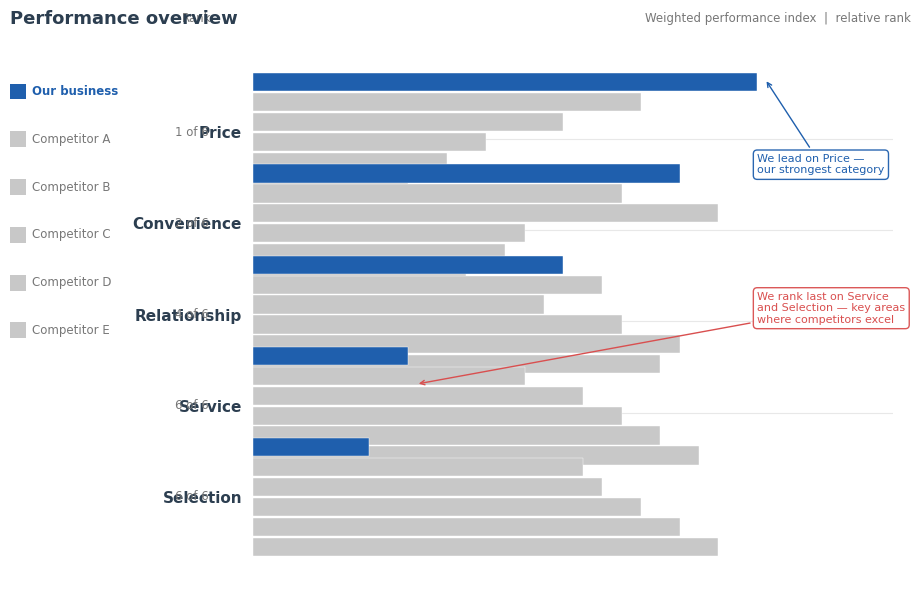

In [6]:
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches

# ── Data: approximated to match the book's rank story ────────────────────────
# Categories ordered by "Our Business" rank (best → worst, top → bottom)
# Ranks from book: Price 1/6, Convenience 2/6, Relationship 4/6,
#                  Service 6/6, Selection 6/6
categories = ['Price', 'Convenience', 'Relationship', 'Service', 'Selection']
ranks       = ['1 of 6', '2 of 6', '4 of 6', '6 of 6', '6 of 6']

# Our Business scores (rescaled to positive index, as book describes)
our_biz = [1.30, 1.10, 0.80, 0.40, 0.30]

# Competitors — set so the rank story is consistent with book
competitors = {
    'Competitor A': [1.00, 0.95, 0.90, 0.70, 0.85],
    'Competitor B': [0.80, 1.20, 0.75, 0.85, 0.90],
    'Competitor C': [0.60, 0.70, 0.95, 0.95, 1.00],
    'Competitor D': [0.50, 0.65, 1.10, 1.05, 1.10],
    'Competitor E': [0.40, 0.55, 1.05, 1.15, 1.20],
}

n_series = 1 + len(competitors)   # Our Biz + 5 competitors

# ── Colours ───────────────────────────────────────────────────────────────────
OUR_BIZ_COLOR = '#1F5FAD'   # strong blue — focal series
COMP_COLOR    = '#C8C8C8'   # light grey — everything else
DARK = '#2C3E50'; GREY_TEXT = '#777777'; WHITE = '#FFFFFF'

bar_height = 0.11
group_gap  = 0.55

fig, ax = plt.subplots(figsize=(9.5, 6.0))
fig.patch.set_facecolor(WHITE)
ax.set_facecolor(WHITE)

# ── Draw bars group by group ──────────────────────────────────────────────────
y_group_centers = []
for i, (cat, rank, our_val) in enumerate(zip(categories, ranks, our_biz)):
    group_top = -(i * group_gap)
    offsets   = [group_top - j * (bar_height + 0.01) for j in range(n_series)]

    # Our Business bar (blue, top of group)
    ax.barh(offsets[0], our_val, height=bar_height,
            color=OUR_BIZ_COLOR, edgecolor=WHITE, linewidth=0.3, zorder=3)

    # Competitor bars (grey, below)
    for k, (_, comp_vals) in enumerate(competitors.items()):
        ax.barh(offsets[k + 1], comp_vals[i], height=bar_height,
                color=COMP_COLOR, edgecolor=WHITE, linewidth=0.3, zorder=3)

    y_group_centers.append((offsets[0] + offsets[-1]) / 2)

# ── Category labels and rank annotations ─────────────────────────────────────
ax.set_yticks(y_group_centers)
ax.set_yticklabels(categories, fontsize=11, fontweight='bold', color=DARK)
ax.tick_params(axis='y', length=0, pad=8)

for ctr, rank in zip(y_group_centers, ranks):
    ax.text(-0.07, ctr, rank, ha='right', va='center',
            fontsize=8.5, color=GREY_TEXT,
            transform=ax.get_yaxis_transform())

# ── X-axis deliberately hidden (SWD design choice — no scale shown) ──────────
ax.set_xticks([])
for spine in ax.spines.values():
    spine.set_visible(False)
ax.set_xlim(0, 1.65)

# ── Thin separator lines between groups ──────────────────────────────────────
for i in range(1, len(categories)):
    ax.axhline(-(i * group_gap) + group_gap * 0.38,
               color='#E8E8E8', lw=0.8, zorder=1)

# ── Left-side legend ─────────────────────────────────────────────────────────
legend_items = [('Our business', OUR_BIZ_COLOR)] + \
               [(c, COMP_COLOR) for c in competitors]
for j, (label, color) in enumerate(legend_items):
    y = 0.92 - j * 0.09
    ax.add_patch(mpatches.FancyBboxPatch(
        (-0.38, y - 0.015), 0.025, 0.03, boxstyle='square,pad=0',
        facecolor=color, edgecolor='none',
        transform=ax.transAxes, clip_on=False, zorder=5))
    ax.text(-0.38 + 0.035, y, label, ha='left', va='center',
            fontsize=8.5, clip_on=False,
            fontweight='bold' if label == 'Our business' else 'normal',
            color=OUR_BIZ_COLOR if label == 'Our business' else GREY_TEXT,
            transform=ax.transAxes)

# ── Column headers ────────────────────────────────────────────────────────────
ax.text(0.82, 1.045, 'Weighted performance index  |  relative rank',
        ha='center', va='bottom', fontsize=8.5, color=GREY_TEXT,
        transform=ax.transAxes)
ax.text(-0.065, 1.045, 'Rank', ha='right', va='bottom',
        fontsize=8.5, color=GREY_TEXT, transform=ax.transAxes)

# ── Title ─────────────────────────────────────────────────────────────────────
ax.set_title('Performance overview', fontsize=13, fontweight='bold',
             color=DARK, loc='left', pad=18, x=-0.38)

# ── Insight annotations ───────────────────────────────────────────────────────
ax.annotate('We rank last on Service\nand Selection — key areas\nwhere competitors excel',
            xy=(0.42, -1.82), xytext=(1.30, -1.45),
            fontsize=8, color='#D94F4F',
            arrowprops=dict(arrowstyle='->', color='#D94F4F', lw=1.0),
            bbox=dict(boxstyle='round,pad=0.35', fc=WHITE, ec='#D94F4F', alpha=0.95))

ax.annotate('We lead on Price —\nour strongest category',
            xy=(1.32, 0.02), xytext=(1.30, -0.55),
            fontsize=8, color=OUR_BIZ_COLOR,
            arrowprops=dict(arrowstyle='->', color=OUR_BIZ_COLOR, lw=1.0),
            bbox=dict(boxstyle='round,pad=0.35', fc=WHITE,
                      ec=OUR_BIZ_COLOR, alpha=0.95))

plt.tight_layout()
plt.show()

Claude Sonnet 4.6